---
title: "06 — ML patches + augmentations"
---

# ML patches — augmentations + tiled inference

The companion to [Patching: grid → process → stitch](05_patching_grids.ipynb).
Same patcher / Field / `gz.patch_ops` machinery, but now the per-chip
work is the **ML inference path**: load → augment (training-time only)
→ model → stitch into a per-pixel classification map.

We demonstrate three slices of the package on a real Sentinel-2 scene:

| Stage | Module | Ops |
|---|---|---|
| Training-chip extraction (irregular sampling) | `geopatcher` | `SpatialJitteredStride` |
| Per-chip augmentation | `gz.augment` | `Compose([RandomFlip, RandomRotate90, BrightnessJitter, GaussianNoise])` |
| Inference + carrier wrap | `gz.ModelOp` | `ModelOp(model, method="predict")` |
| Vote-stitching of classification labels | `geopatcher` | `SpatialHardVote(n_classes=3)` |

The "model" is a rule-based three-class classifier driven by NDVI +
NDWI thresholds — water (0), bare/scrub (1), vegetation (2). It plays
the role of any real sklearn / PyTorch estimator: anything with a
`predict` method (or `__call__`) plugs into `ModelOp` interchangeably.

In [1]:
import geopatcher as gp
import geotoolz as gz
import matplotlib.pyplot as plt
import numpy as np
import planetary_computer
import pystac_client
import rioxarray
from geopatcher.fields import RasterField
from georeader.geotensor import GeoTensor
from geotoolz.patch_ops import ApplyToChips, GridSampler, Stitch
from matplotlib.colors import ListedColormap
from rasterio.enums import Resampling

## 1. Load one Sentinel-2 scene

Lake Tahoe, same scene as the companion patching notebook. BGRN
(4 bands) — we want green + NIR for NDWI and red + NIR for NDVI.

In [2]:
BBOX = (-120.10, 38.92, -119.93, 39.27)

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
items = sorted(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=BBOX,
        datetime="2024-06-01/2024-07-15",
        query={
            "eo:cloud_cover": {"lt": 5},
            "s2:mgrs_tile": {"eq": "10SGJ"},
        },
    ).items(),
    key=lambda x: x.properties["eo:cloud_cover"],
)
item = items[0]
print(f"using {item.id}")

using S2B_MSIL2A_20240614T183919_R070_T10SGJ_20240615T003207


In [3]:
def _load(key, *, ref=None, resampling=Resampling.bilinear):
    da = rioxarray.open_rasterio(item.assets[key].href, masked=False)
    da = da.squeeze("band", drop=True).rio.clip_box(*BBOX, crs="EPSG:4326")
    if ref is not None:
        da = da.rio.reproject_match(ref, resampling=resampling)
    return da


red = _load("B04")
green = _load("B03", ref=red)
blue = _load("B02", ref=red)
nir = _load("B08", ref=red)

# Reflectance up front so augmentations and the model see physical units.
dn_stack = np.stack([blue.values, green.values, red.values, nir.values], axis=0).astype(
    "uint16"
)
refl = gz.radiometry.DNToReflectance(scale=1e-4)(
    GeoTensor(
        values=dn_stack,
        transform=red.rio.transform(),
        crs=red.rio.crs,
        fill_value_default=0,
    )
)
print(f"reflectance carrier: shape={refl.shape}  dtype={refl.dtype}")

reflectance carrier: shape=(4, 3935, 1599)  dtype=float64


## 2. Training-chip sampling — `SpatialJitteredStride`

For a *training dataset* we don't want a regular grid (every chip
lines up the same way and overfits to position); we want **jittered**
anchors so the model sees translated variants of similar terrain.
`SpatialJitteredStride(step, jitter)` perturbs each regular-grid
anchor by a uniform random offset bounded by `jitter` pixels.

Compare to **`SpatialPoissonDisk`** — Poisson-disk sampling places
anchors as far apart as possible (minimum-distance constraint),
giving the most spatially-diverse training chips. Use it when training
samples are expensive (annotated labels) and you want maximum
coverage per chip.

In [4]:
field = RasterField(reader=refl)
train_patcher = gp.SpatialPatcher(
    geometry=gp.SpatialRectangular(size=(128, 128)),
    # jitter is in step-units (0.0 = none, 0.5 = ± half a step), so
    # 0.25 of a 192-px step gives ±48 px of jitter per anchor.
    sampler=gp.SpatialJitteredStride(step=(192, 192), jitter=0.25, seed=0),
    window=gp.SpatialBoxcar(),
    aggregation=gp.SpatialOverlapAdd(),
)
train_chips = list(train_patcher.split(field))
print(f"sampled {len(train_chips)} training chips of size 128×128")

sampled 160 training chips of size 128×128


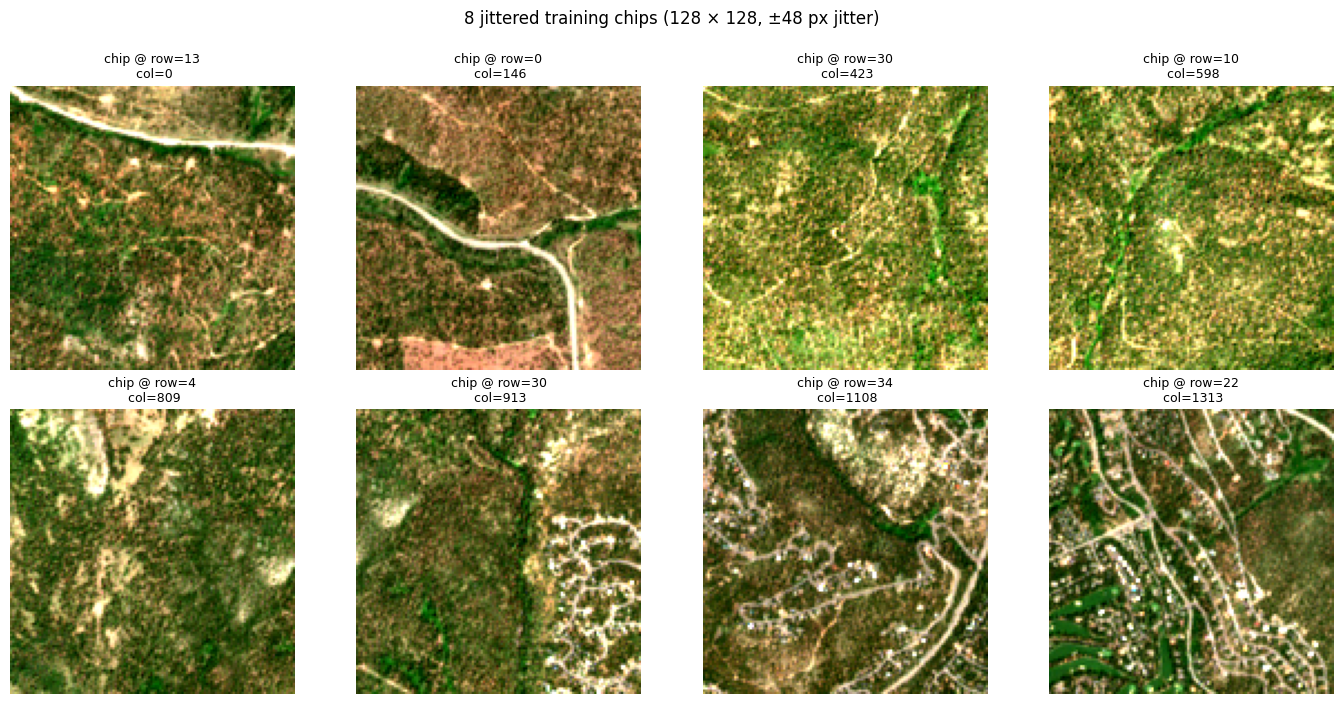

In [5]:
def _rgb(arr):
    """(C, H, W) reflectance → (H, W, 3) display range."""
    rgb = np.transpose(arr[[2, 1, 0]], (1, 2, 0))  # R, G, B
    lo, hi = np.nanpercentile(rgb, [2, 98])
    return np.clip((rgb - lo) / (hi - lo + 1e-9), 0, 1)


fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, chip in zip(axes.flat, train_chips[:8], strict=False):
    ax.imshow(_rgb(np.asarray(chip.data)))
    ax.set_title(
        f"chip @ row={chip.indices.row_off}\n col={chip.indices.col_off}",
        fontsize=9,
    )
    ax.axis("off")
fig.suptitle("8 jittered training chips (128 × 128, ±48 px jitter)", y=1.0)
plt.tight_layout()
plt.show()

## 3. Augment one chip with `gz.augment.Compose`

A typical RS-safe augmentation pipeline: random flips, 90°
rotations, brightness jitter (multiplicative gain), and Gaussian
sensor noise. Each `gz.augment.*` op:

- preserves CRS and updates the affine `transform` (so flips and
  rotations still map to the right world coordinates),
- is reproducible — pass `seed=...` for a deterministic draw or omit
  for entropy from the OS,
- composes via `gz.augment.Compose(ops, p=...)` so the whole chain has
  a single overall-probability gate.

Compose(augmentations=[{'class': 'RandomFlip', 'config': {'p_horizontal': 0.5, 'p_vertical': 0.5, 'seed': None}}, {'class': 'RandomRotate90', 'config': {'p': 0.75, 'seed': None}}, {'class': 'BrightnessJitter', 'config': {'factor': (0.85, 1.15), 'per_band': True, 'seed': None}}, {'class': 'GaussianNoise', 'config': {'sigma': 0.01, 'per_band': True, 'seed': None}}], p=1.0, seed=None)


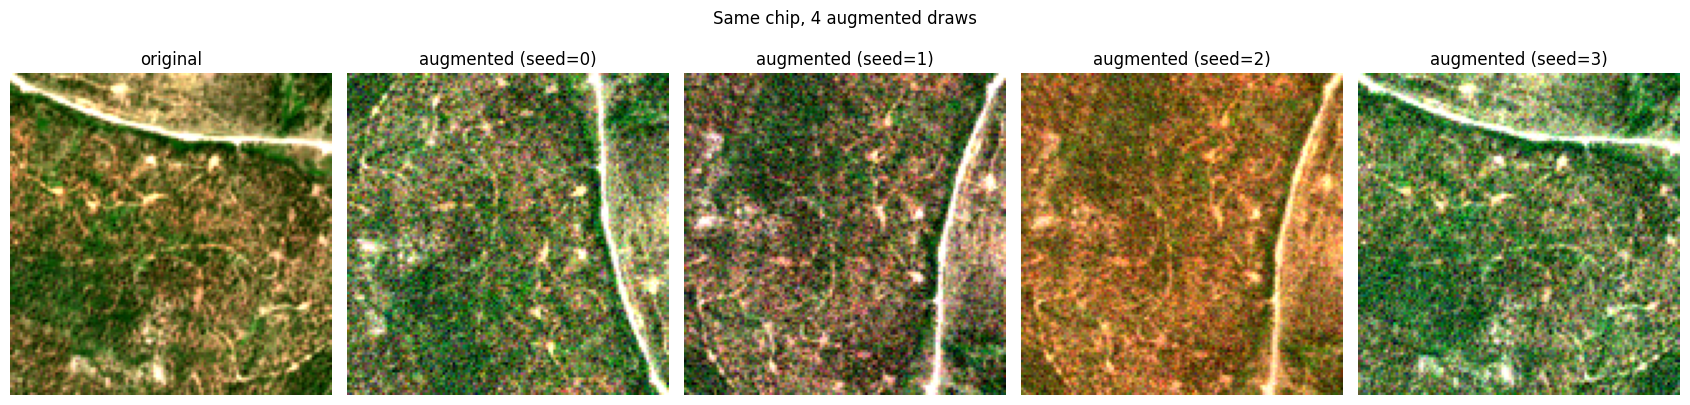

In [6]:
augment = gz.augment.Compose(
    [
        gz.augment.RandomFlip(p_horizontal=0.5, p_vertical=0.5),
        gz.augment.RandomRotate90(p=0.75),
        gz.augment.BrightnessJitter(factor=(0.85, 1.15), per_band=True),
        gz.augment.GaussianNoise(sigma=0.01),
    ],
    p=1.0,
)
print(augment)

base = train_chips[0].data
fig, axes = plt.subplots(1, 5, figsize=(17, 4))
axes[0].imshow(_rgb(np.asarray(base)))
axes[0].set_title("original")
axes[0].axis("off")
for ax, seed in zip(axes[1:], range(4), strict=True):
    aug = augment(base, seed=seed)
    ax.imshow(_rgb(np.asarray(aug)))
    ax.set_title(f"augmented (seed={seed})")
    ax.axis("off")
fig.suptitle("Same chip, 4 augmented draws", y=1.02)
plt.tight_layout()
plt.show()

Notice each draw is *different* (flips, rotations, brightness shifts
all sample independently per seed) but always preserves the CRS +
spatial extent semantics. That's the reproducible-RS-augmentation
contract `gz.augment` enforces.

## 4. A three-class rule-based "model"

To keep this notebook self-contained we use a small NDVI / NDWI
threshold rule as our classifier. **Any callable with a `predict`
method (sklearn) or `__call__` (PyTorch / JAX) drops in via
`gz.ModelOp` the same way** — `ModelOp` is the substrate adapter.

Classes:

| id | name | rule |
|---|---|---|
| 0 | Water | `NDWI > 0.1` |
| 1 | Bare / scrub | `NDVI < 0.25` and not water |
| 2 | Vegetation | `NDVI ≥ 0.25` |

In [7]:
class NDVIClassifier:
    """Rule-based 3-class classifier with the sklearn-style `predict` API."""

    def predict(self, x: np.ndarray) -> np.ndarray:
        # x is (4, H, W) reflectance — B(0) G(1) R(2) NIR(3).
        green, red, nir_ = x[1], x[2], x[3]
        ndvi = (nir_ - red) / (nir_ + red + 1e-10)
        ndwi = (green - nir_) / (green + nir_ + 1e-10)
        labels = np.full(ndvi.shape, 1, dtype=np.int64)  # default: bare/scrub
        labels[ndwi > 0.1] = 0  # water
        labels[ndvi >= 0.25] = 2  # vegetation
        return labels


model_op = gz.ModelOp(NDVIClassifier(), method="predict")
print(model_op)

# Smoke-test on a single chip.
sample_out = model_op(base)
print(f"single-chip output: shape={sample_out.shape}  dtype={sample_out.dtype}")
print(f"class counts:      {np.bincount(np.asarray(sample_out).ravel(), minlength=3)}")

ModelOp(model_type='NDVIClassifier', method='predict', batch_size=None)
single-chip output: shape=(128, 128)  dtype=int64
class counts:      [    0   926 15458]


## 5. Tiled inference — `Sequential([GridSampler, ApplyToChips, Stitch])`

Now the full pipeline. The per-chip op is `ModelOp(...)` instead of
the NDVI from the previous notebook; the aggregation is
`SpatialHardVote(n_classes=3)` instead of `SpatialOverlapAdd` because
we are stitching **integer class labels**, not continuous values.

For inference we also use a denser, *non-jittered* sampler
(`SpatialRegularStride`) — jitter is a training-time trick, not an
inference-time one.

In [8]:
infer_patcher = gp.SpatialPatcher(
    geometry=gp.SpatialRectangular(size=(256, 256)),
    sampler=gp.SpatialRegularStride(step=(256, 256)),
    window=gp.SpatialBoxcar(),
    aggregation=gp.SpatialHardVote(n_classes=3),
)
inference = gz.Sequential(
    [
        GridSampler(patcher=infer_patcher),
        ApplyToChips(operator=model_op),
        Stitch(aggregation=infer_patcher.aggregation, domain=field.domain),
    ]
)
print(inference)

class_map = np.asarray(inference(field))
# Domain has channel axis (4, H, W); SpatialHardVote produces (4, H, W)
# with each channel a duplicate of the (H, W) vote map. Collapse:
if class_map.ndim == 3:
    class_map = class_map[0]
print(f"classification map: shape={class_map.shape}  dtype={class_map.dtype}")
print(f"class counts:      {np.bincount(class_map.ravel(), minlength=3)}")

Sequential([GridSampler(patcher={'geometry': {'class': 'SpatialRectangular', 'config': {'size': [256, 256]}}, 'sampler': {'class': 'SpatialRegularStride', 'config': {'step': [256, 256]}}, 'window': {'class': 'SpatialBoxcar', 'config': {}}, 'aggregation': {'class': 'SpatialHardVote', 'config': {'n_classes': 3}}}), ApplyToChips(operator={'class': 'ModelOp', 'config': {'model_type': 'NDVIClassifier', 'method': 'predict', 'batch_size': None}}), Stitch(aggregation={'class': 'SpatialHardVote', 'config': {'n_classes': 3}})])


classification map: shape=(3935, 1599)  dtype=int64
class counts:      [ 546953 4559300 1185812]


## 6. Compare against full-scene inference

Run the *same* model on the whole scene without patching as a
reference. The patched output should match across the interior.

per-pixel agreement: 93.76%


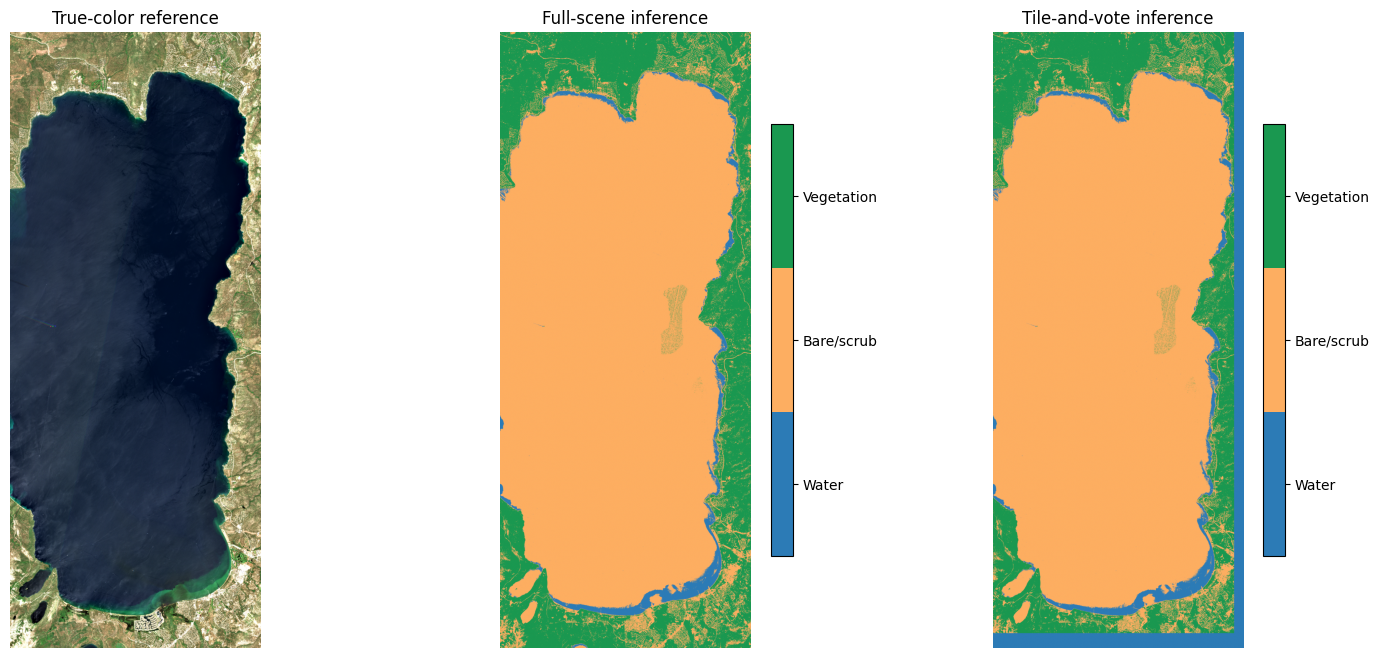

In [9]:
full_class_map = np.asarray(model_op(refl))
agree = float(np.mean(class_map == full_class_map))
print(f"per-pixel agreement: {agree * 100:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

labels = ["Water", "Bare/scrub", "Vegetation"]
class_cmap = ListedColormap(["#2c7bb6", "#fdae61", "#1a9850"])

axes[0].imshow(_rgb(np.asarray(refl)))
axes[0].set_title("True-color reference")
axes[0].axis("off")

im1 = axes[1].imshow(full_class_map, cmap=class_cmap, vmin=-0.5, vmax=2.5)
axes[1].set_title("Full-scene inference")
axes[1].axis("off")
cbar = fig.colorbar(im1, ax=axes[1], shrink=0.7, ticks=range(3))
cbar.ax.set_yticklabels(labels)

im2 = axes[2].imshow(class_map, cmap=class_cmap, vmin=-0.5, vmax=2.5)
axes[2].set_title("Tile-and-vote inference")
axes[2].axis("off")
cbar = fig.colorbar(im2, ax=axes[2], shrink=0.7, ticks=range(3))
cbar.ax.set_yticklabels(labels)
plt.show()

## 7. Recap

The same three-op patching pattern from
[05_patching_grids.ipynb](05_patching_grids.ipynb) hosts the ML inference
path with **zero structural change** — only the parts that need to
vary do:

| What | Patching demo | ML demo |
|---|---|---|
| Sampler | `SpatialRegularStride` (every pixel covered) | `SpatialJitteredStride` (training) or `SpatialRegularStride` (inference) |
| Window | `SpatialHann` (smooth blending) | `SpatialBoxcar` (votes don't need blending) |
| Per-chip op | NDVI | `gz.ModelOp(model, method="predict")` |
| Aggregation | `SpatialOverlapAdd` (continuous map) | `SpatialHardVote(n_classes=K)` (class labels) |

Other building blocks worth pairing in:

- **`gz.augment`** — `Compose([RandomFlip, RandomRotate90, BrightnessJitter, GaussianNoise, AtmosphericHaze, SimulatedClouds, CutMix, ...])` for training-chip augmentation. Each op preserves CRS / `transform` so the augmented carrier is still geographically valid.
- **`SklearnOp`** — `gz.learn.SklearnOp(estimator, mode="pixel")` if you want a *fitted* sklearn estimator (RandomForestClassifier, GBM, kNN, …) instead of a hand-coded rule.
- **`SpatialSoftVote`** — like `HardVote` but stitches per-class
  probabilities (chip outputs shape `(K, H, W)`), letting you
  threshold or compute class margins at the field level.
- **`Profile` + `ShapeTrace`** from [the observability section of operators_lake_tahoe](03_operators_lake_tahoe.ipynb) — wrap `ModelOp` to time per-chip inference cost across the run.

For the cross-package walk-through (STAC → catalog → patcher →
operators), see [`geocatalog/docs/notebooks/end_to_end_lake_tahoe.ipynb`](https://github.com/jejjohnson/geocatalog/blob/main/docs/notebooks/end_to_end_lake_tahoe.ipynb).